# 08 — Final Model Interpretability

This notebook investigates how the finalized Histogram Gradient Boosting
model produces Remaining Useful Life predictions for the official NASA
C-MAPSS FD001 test engines.

The previous notebook completed the official test evaluation and persisted
the final model artifact. Predictive performance alone, however, does not
explain which measurements drive the model or why individual predictions
are produced.

This notebook therefore evaluates the final model from two complementary
perspectives:

1. **Global interpretability**  
   Which features are most important across the official test dataset?

2. **Local interpretability**  
   Which features increase or decrease the predicted Remaining Useful Life
   for an individual engine?

The analysis uses:

- permutation feature importance,
- SHAP feature attribution,
- global importance plots,
- feature-effect analysis,
- individual prediction explanations.

Interpretability results describe the behaviour of the fitted model.
They should not be interpreted as evidence of physical causality.

In [42]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

In [43]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/alirezakafi/Documents/Code Repo/nasa-turbofan-predictive-maintenance


In [44]:
from src.config import EMA_SPAN, ROLLING_WINDOW, RUL_CAP
from src.data_loader import load_cmapss_data, load_rul_labels
from src.preprocessing import add_sensor_history_features

In [45]:
print("ROLLING_WINDOW:", ROLLING_WINDOW)
print("EMA_SPAN:", EMA_SPAN)
print("RUL_CAP:", RUL_CAP)
print("SHAP version:", shap.__version__)

ROLLING_WINDOW: 10
EMA_SPAN: 10
RUL_CAP: 125
SHAP version: 0.49.1


## 1. Load the Final Persisted Model

Notebook 07 retrained the finalized Histogram Gradient Boosting model on
the complete FD001 training dataset and saved it as a reusable artifact.

The artifact contains not only the fitted estimator but also the finalized
feature specification, selected sensors, target definition, model
parameters, and official test metrics.

Loading this artifact prevents the interpretability notebook from silently
redefining or retraining a different model.

In [46]:
MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "hist_gradient_boosting_fd001.joblib"
)

assert MODEL_PATH.exists(), (
    f"Final model artifact was not found: {MODEL_PATH}"
)

model_bundle = joblib.load(MODEL_PATH)

final_model = model_bundle["model"]
feature_columns = model_bundle["feature_columns"]
selected_sensors = model_bundle["selected_sensors"]

print("Loaded model:", model_bundle["model_name"])
print("Dataset:", model_bundle["dataset"])
print("Number of features:", len(feature_columns))
print("Selected sensors:", selected_sensors)

Loaded model: HistGradientBoostingRegressor
Dataset: NASA C-MAPSS FD001
Number of features: 51
Selected sensors: ['s2', 's3', 's4', 's7', 's11', 's12', 's15', 's17', 's20', 's21']


In [47]:
assert model_bundle["model_name"] == "HistGradientBoostingRegressor"

assert len(feature_columns) == 51

assert len(selected_sensors) == 10

assert len(set(feature_columns)) == len(feature_columns)

assert model_bundle["target_column"] == "RUL"

print("Final model artifact validation passed.")

Final model artifact validation passed.


## 2. Rebuild the Official Test Endpoint Dataset

The persisted artifact contains the finalized model and feature
specification, but interpretability still requires the exact input rows
used during official evaluation.

The official FD001 test dataset contains incomplete trajectories.

Therefore, the model produces one Remaining Useful Life prediction for
the final observed cycle of each test engine.

The same causal feature-engineering pipeline used during model training
and official evaluation is reconstructed below.

In [48]:
test_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "test_FD001.txt"
)

rul_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "RUL_FD001.txt"
)

test_df = load_cmapss_data(test_path)

test_rul_raw = (
    load_rul_labels(rul_path)
    .reset_index(drop=True)
)

print("Test shape:", test_df.shape)
print("Test engines:", test_df["id"].nunique())
print("Official RUL labels:", len(test_rul_raw))

Test shape: (13096, 26)
Test engines: 100
Official RUL labels: 100


In [49]:
assert test_df.shape[0] == 13096
assert test_df["id"].nunique() == 100

assert len(test_rul_raw) == 100

assert test_df.isna().sum().sum() == 0
assert test_rul_raw.isna().sum().sum() == 0

print("Official FD001 test files validated.")

Official FD001 test files validated.


In [50]:
test_processed = add_sensor_history_features(
    test_df,
    sensors=selected_sensors,
    rolling_window=ROLLING_WINDOW,
    ema_span=EMA_SPAN,
).reset_index(drop=True)

print(
    "Processed test shape:",
    test_processed.shape,
)

Processed test shape: (13096, 66)


In [51]:
assert len(test_processed) == len(test_df)

assert all(
    column in test_processed.columns
    for column in feature_columns
)

assert (
    test_processed[feature_columns]
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    test_processed[
        feature_columns
    ].to_numpy()
).all()

print("Official test feature pipeline validated.")

Official test feature pipeline validated.


In [52]:
test_endpoints = (
    test_processed
    .sort_values(["id", "cycle"])
    .groupby("id", as_index=False)
    .tail(1)
    .sort_values("id")
    .reset_index(drop=True)
)

print(
    "Official endpoint shape:",
    test_endpoints.shape,
)

display(
    test_endpoints[
        ["id", "cycle"]
    ].head(10)
)

Official endpoint shape: (100, 66)


,id,cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98
5,6,105
6,7,160
7,8,166
8,9,55
9,10,192


In [53]:
assert len(test_endpoints) == 100
assert test_endpoints["id"].is_unique

assert len(test_endpoints) == len(
    test_rul_raw
)

assert test_endpoints["id"].tolist() == list(
    range(1, 101)
)

expected_final_cycles = (
    test_df
    .groupby("id")["cycle"]
    .max()
    .sort_index()
    .to_numpy()
)

assert np.array_equal(
    test_endpoints["cycle"].to_numpy(),
    expected_final_cycles,
)

print(
    "Official test endpoints and labels "
    "are correctly aligned."
)

Official test endpoints and labels are correctly aligned.


In [54]:
X_official_test = (
    test_endpoints[
        feature_columns
    ]
    .copy()
)

y_test_raw = (
    test_rul_raw
    .astype(float)
    .reset_index(drop=True)
)

y_test_capped = (
    y_test_raw
    .clip(upper=RUL_CAP)
)

print(
    "Official test feature matrix:",
    X_official_test.shape,
)

print(
    "Raw target shape:",
    y_test_raw.shape,
)

print(
    "Capped target shape:",
    y_test_capped.shape,
)

Official test feature matrix: (100, 51)
Raw target shape: (100,)
Capped target shape: (100,)


In [55]:
assert X_official_test.shape == (100, 51)
assert y_test_raw.shape == (100,)
assert y_test_capped.shape == (100,)

assert list(
    X_official_test.columns
) == feature_columns

assert (
    X_official_test
    .isna()
    .sum()
    .sum()
    == 0
)

assert np.isfinite(
    X_official_test.to_numpy()
).all()

assert y_test_raw.min() >= 0

assert y_test_capped.between(
    0,
    RUL_CAP,
).all()

print(
    "Official interpretability dataset validated."
)

Official interpretability dataset validated.


## 3. Verify the Persisted Model Predictions

Before interpreting the model, its predictions must reproduce the
official evaluation results stored in the artifact.

This check protects the analysis from several possible errors:

- incorrect feature order,
- inconsistent preprocessing,
- misaligned test labels,
- accidental use of a different model,
- accidental use of non-endpoint observations.

The model's raw predictions are generated first.

The same target-range constraint used during official evaluation is then
applied:

$$
0 \leq \widehat{\mathrm{RUL}} \leq 125
$$

In [56]:
predictions_raw = final_model.predict(
    X_official_test
)

predictions_constrained = np.clip(
    predictions_raw,
    0,
    RUL_CAP,
)

print(
    "Raw prediction range:",
    predictions_raw.min(),
    predictions_raw.max(),
)

print(
    "Constrained prediction range:",
    predictions_constrained.min(),
    predictions_constrained.max(),
)

print(
    "Predictions below zero:",
    int(
        (
            predictions_raw < 0
        ).sum()
    ),
)

print(
    "Predictions above cap:",
    int(
        (
            predictions_raw > RUL_CAP
        ).sum()
    ),
)

Raw prediction range: 4.2287707524979 124.83726064089416
Constrained prediction range: 4.2287707524979 124.83726064089416
Predictions below zero: 0
Predictions above cap: 0


In [57]:
official_mae = mean_absolute_error(
    y_test_capped,
    predictions_constrained,
)

stored_mae = (
    model_bundle[
        "official_test_metrics"
    ][
        "capped_RUL"
    ][
        "MAE"
    ]
)

print(
    f"Recomputed official MAE: "
    f"{official_mae:.6f}"
)

print(
    f"Stored official MAE: "
    f"{stored_mae:.6f}"
)

Recomputed official MAE: 10.115908
Stored official MAE: 10.115908


In [58]:
assert np.isclose(
    official_mae,
    stored_mae,
    rtol=1e-10,
    atol=1e-10,
)

assert len(predictions_raw) == 100

assert np.isfinite(
    predictions_raw
).all()

assert predictions_constrained.min() >= 0
assert predictions_constrained.max() <= RUL_CAP

print(
    "Persisted model reproduces "
    "the official evaluation result."
)

Persisted model reproduces the official evaluation result.


In [59]:
prediction_summary = pd.DataFrame(
    {
        "engine_id": test_endpoints["id"],
        "final_cycle": test_endpoints["cycle"],
        "actual_RUL": y_test_capped,
        "predicted_RUL_raw": predictions_raw,
        "predicted_RUL_constrained": (
            predictions_constrained
        ),
    }
)

prediction_summary["absolute_error"] = (
    prediction_summary[
        "predicted_RUL_constrained"
    ]
    - prediction_summary[
        "actual_RUL"
    ]
).abs()

display(
    prediction_summary.head(10)
)

,engine_id,final_cycle,actual_RUL,predicted_RUL_raw,predicted_RUL_constrained,absolute_error
0,1,31,112.0,124.837261,124.837261,12.837261
1,2,49,98.0,121.997148,121.997148,23.997148
2,3,126,69.0,70.425438,70.425438,1.425438
3,4,106,82.0,67.637710,67.637710,14.362290
4,5,98,91.0,77.787167,77.787167,13.212833
5,6,105,93.0,106.462614,106.462614,13.462614
6,7,160,91.0,96.424425,96.424425,5.424425
7,8,166,95.0,92.902523,92.902523,2.097477
8,9,55,111.0,119.968978,119.968978,8.968978
9,10,192,96.0,75.526825,75.526825,20.473175


## 4. Global Interpretability with Permutation Importance

Histogram Gradient Boosting does not expose a native
`feature_importances_` attribute.

Permutation importance provides a model-agnostic alternative.

For each feature, the method randomly shuffles that feature while keeping
all other columns unchanged.

If shuffling a feature substantially worsens model performance, the model
depends strongly on that feature.

In this notebook:

- the scoring metric is negative Mean Absolute Error,
- the official test endpoints form the evaluation dataset,
- each feature is shuffled repeatedly,
- larger positive importance indicates a larger increase in error after
  permutation.

Permutation importance measures predictive dependence, not physical
causality.

In [60]:
permutation_result = permutation_importance(
    estimator=final_model,
    X=X_official_test,
    y=y_test_capped,
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)

print(
    "Permutation importance completed."
)

Permutation importance completed.


In [61]:
permutation_importance_df = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "importance_mean": (
                permutation_result
                .importances_mean
            ),
            "importance_std": (
                permutation_result
                .importances_std
            ),
        }
    )
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    permutation_importance_df.head(20)
)

,feature,importance_mean,importance_std
0,cycle,2.973254,0.633275
1,s4_ema_10,2.906068,0.501962
2,s12_expanding_mean,2.236831,0.795498
3,s20_expanding_mean,1.903677,0.461115
4,s15_rolling_mean_10,1.731832,0.470042
5,s11_ema_10,1.423358,0.352249
6,s4_rolling_mean_10,1.209755,0.340394
7,s11_rolling_mean_10,1.186559,0.333616
8,s2_rolling_mean_10,1.093256,0.283538
9,s21_rolling_mean_10,1.022098,0.290343


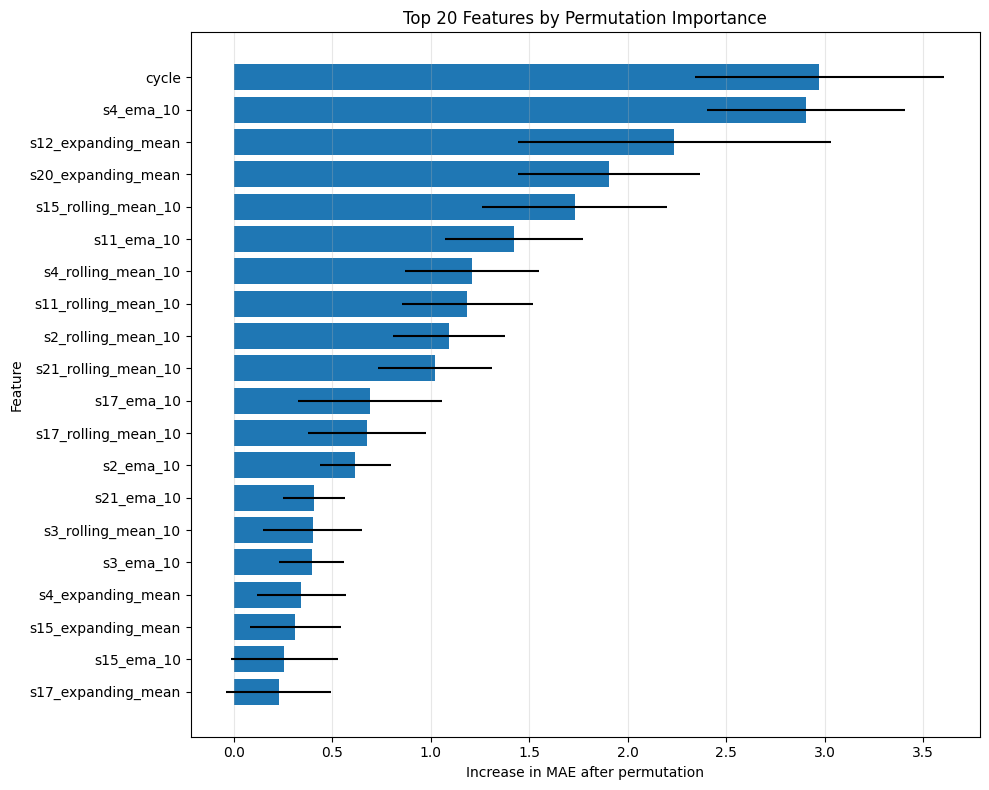

In [62]:
top_n = 20

top_permutation_features = (
    permutation_importance_df
    .head(top_n)
    .sort_values(
        "importance_mean",
        ascending=True,
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_permutation_features[
        "feature"
    ],
    top_permutation_features[
        "importance_mean"
    ],
    xerr=top_permutation_features[
        "importance_std"
    ],
)

plt.xlabel(
    "Increase in MAE after permutation"
)

plt.ylabel("Feature")

plt.title(
    "Top 20 Features by Permutation Importance"
)

plt.grid(
    axis="x",
    alpha=0.3,
)

plt.tight_layout()

plt.show()

## 5. Global and Local Interpretability with SHAP

Permutation importance measures how much model performance deteriorates
when information from a feature is destroyed.

SHAP answers a different question.

Instead of measuring global dependence, SHAP explains how every feature
contributes to an individual prediction.

Each SHAP value represents the contribution of one feature toward moving
the prediction away from the model's baseline prediction.

Positive SHAP values increase the predicted Remaining Useful Life,
whereas negative values decrease it.

SHAP therefore provides both:

- global explanations across the complete dataset,
- local explanations for individual engines.

In [63]:
explainer = shap.Explainer(
    final_model,
    X_official_test,
)

print(type(explainer))

<class 'shap.explainers._tree.TreeExplainer'>


In [65]:
shap_values = explainer(
    X_official_test,
    check_additivity=False,
)

print("SHAP values shape:", shap_values.values.shape)

SHAP values shape: (100, 51)


In [ ]:
assert shap_values.values.shape == X_official_test.shape

assert np.isfinite(
    shap_values.values
).all()

print("SHAP values computed successfully.")

In [66]:
shap_reconstructed_predictions = (
    np.asarray(shap_values.base_values).reshape(-1)
    + shap_values.values.sum(axis=1)
)

shap_additivity_error = (
    shap_reconstructed_predictions
    - predictions_raw
)

print(
    "Maximum absolute SHAP additivity error:",
    np.abs(shap_additivity_error).max(),
)

print(
    "Mean absolute SHAP additivity error:",
    np.abs(shap_additivity_error).mean(),
)

print(
    "Median absolute SHAP additivity error:",
    np.median(
        np.abs(shap_additivity_error)
    ),
)

Maximum absolute SHAP additivity error: 1.4086774831814353
Mean absolute SHAP additivity error: 0.05197796199338522
Median absolute SHAP additivity error: 0.0072097944127875735


In [67]:
shap_additivity_summary = pd.DataFrame(
    {
        "engine_id": test_endpoints["id"],
        "model_prediction": predictions_raw,
        "shap_reconstructed_prediction": (
            shap_reconstructed_predictions
        ),
        "absolute_additivity_error": (
            np.abs(shap_additivity_error)
        ),
    }
)

display(
    shap_additivity_summary
    .sort_values(
        "absolute_additivity_error",
        ascending=False,
    )
    .head(10)
)

,engine_id,model_prediction,shap_reconstructed_prediction,absolute_additivity_error
72,73,94.610296,93.201619,1.408677
56,57,88.079602,89.103233,1.023631
19,20,14.430551,13.407410,1.023141
73,74,106.224428,106.592412,0.367984
79,80,83.844482,84.080331,0.235849
53,54,120.963481,120.801340,0.162141
62,63,67.007459,67.124149,0.116690
37,38,73.549543,73.637941,0.088398
74,75,117.871520,117.931725,0.060205
13,14,120.199535,120.244463,0.044927


### SHAP Additivity Check

TreeExplainer's strict additivity check was disabled because it produced
a numerical mismatch for the scikit-learn Histogram Gradient Boosting
model.

The feature matrix and model artifact were independently validated before
the SHAP analysis.

To avoid hiding the discrepancy, the SHAP-based reconstructed predictions
were compared directly with the model predictions.

The reported additivity errors quantify the numerical approximation gap
and should be considered when interpreting individual explanations.

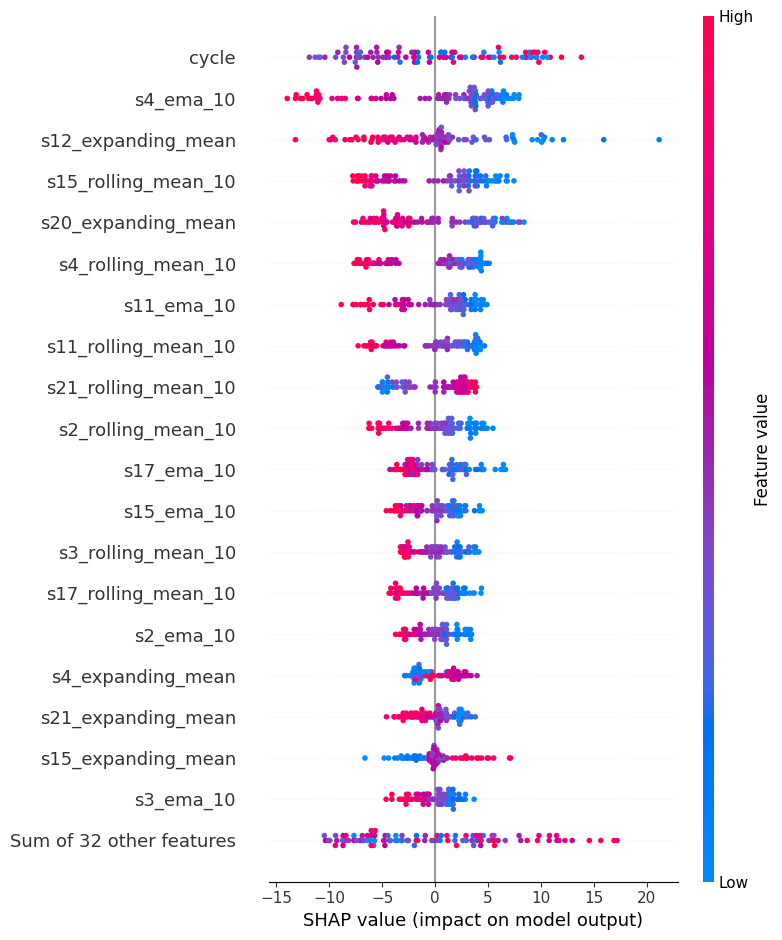

In [68]:
plt.figure(figsize=(10, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False,
)

plt.tight_layout()

plt.show()

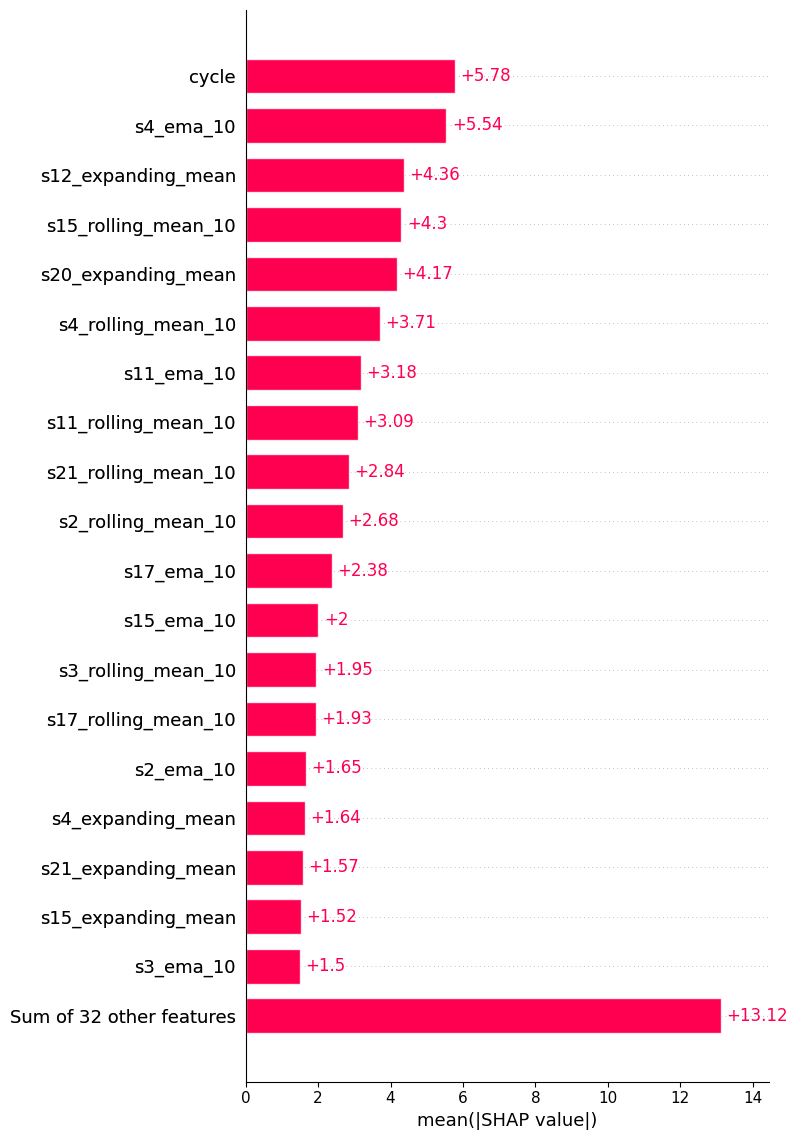

In [69]:
plt.figure(figsize=(8, 8))

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False,
)

plt.tight_layout()

plt.show()

In [70]:
mean_abs_shap = (
    np.abs(shap_values.values)
    .mean(axis=0)
)

shap_importance = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "mean_abs_shap": mean_abs_shap,
        }
    )
    .sort_values(
        "mean_abs_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(shap_importance.head(20))

,feature,mean_abs_shap
0,cycle,5.776310
1,s4_ema_10,5.541751
2,s12_expanding_mean,4.359634
3,s15_rolling_mean_10,4.295148
4,s20_expanding_mean,4.174101
5,s4_rolling_mean_10,3.707849
6,s11_ema_10,3.183546
7,s11_rolling_mean_10,3.094923
8,s21_rolling_mean_10,2.844548
9,s2_rolling_mean_10,2.675438


In [71]:
comparison = (
    permutation_importance_df[
        ["feature", "importance_mean"]
    ]
    .merge(
        shap_importance,
        on="feature",
    )
)

display(
    comparison.head(20)
)

,feature,importance_mean,mean_abs_shap
0,cycle,2.973254,5.776310
1,s4_ema_10,2.906068,5.541751
2,s12_expanding_mean,2.236831,4.359634
3,s20_expanding_mean,1.903677,4.174101
4,s15_rolling_mean_10,1.731832,4.295148
5,s11_ema_10,1.423358,3.183546
6,s4_rolling_mean_10,1.209755,3.707849
7,s11_rolling_mean_10,1.186559,3.094923
8,s2_rolling_mean_10,1.093256,2.675438
9,s21_rolling_mean_10,1.022098,2.844548


## 6. Individual Prediction Explanation

Global feature importance describes the overall behaviour of the model.

SHAP can also explain why a single engine receives a particular
Remaining Useful Life prediction.

The following example visualizes one individual engine from the official
NASA FD001 test set.

In [72]:
engine_index = 0

print(
    prediction_summary.iloc[
        engine_index
    ]
)

engine_id                      1.000000
final_cycle                   31.000000
actual_RUL                   112.000000
predicted_RUL_raw            124.837261
predicted_RUL_constrained    124.837261
absolute_error                12.837261
Name: 0, dtype: float64


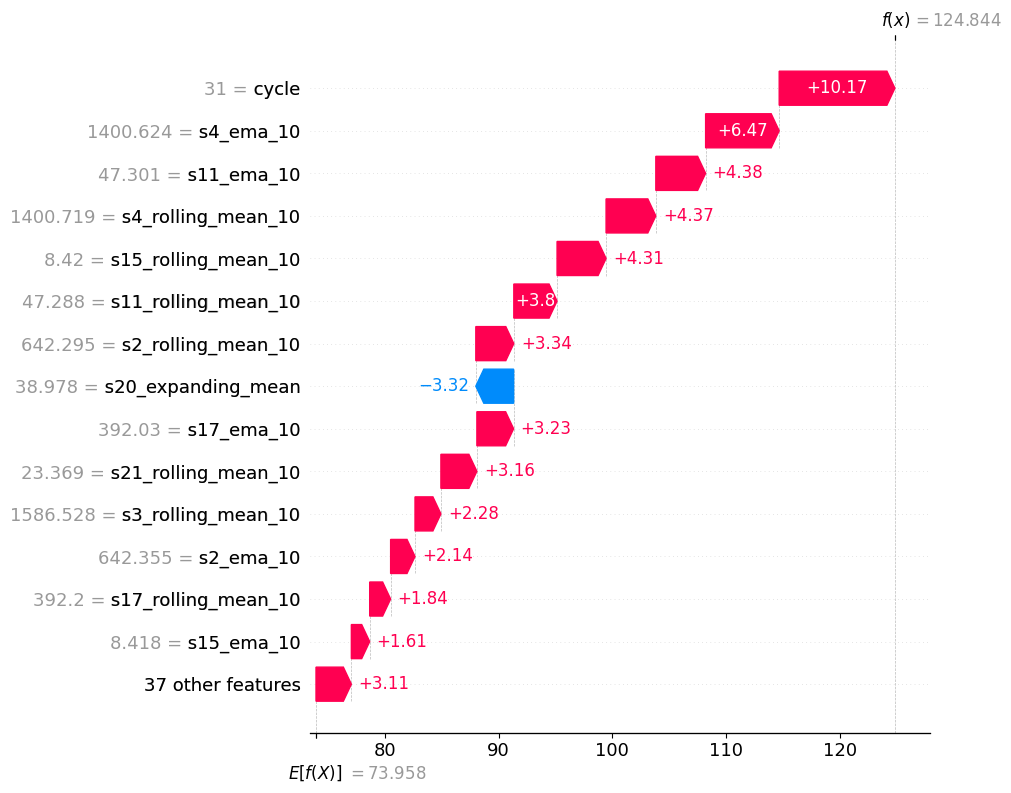

In [73]:
shap.plots.waterfall(
    shap_values[
        engine_index
    ],
    max_display=15,
)

### Best Prediction

This example corresponds to the official test engine with the smallest
absolute prediction error.

It illustrates a prediction where the finalized Histogram Gradient
Boosting model closely matches the ground-truth Remaining Useful Life.

The SHAP explanation highlights the feature contributions associated
with one of the model's most accurate predictions.

In [74]:
best_prediction = prediction_summary["absolute_error"].idxmin()

worst_prediction = prediction_summary["absolute_error"].idxmax()

median_prediction = (
    prediction_summary["absolute_error"]
    .sub(
        prediction_summary["absolute_error"].median()
    )
    .abs()
    .idxmin()
)

print("Best prediction index:", best_prediction)
print("Median prediction index:", median_prediction)
print("Worst prediction index:", worst_prediction)

Best prediction index: 76
Median prediction index: 84
Worst prediction index: 44


In [75]:
engine_index = best_prediction

prediction_summary.iloc[engine_index]

engine_id                     77.000000
final_cycle                  162.000000
actual_RUL                    34.000000
predicted_RUL_raw             33.977047
predicted_RUL_constrained     33.977047
absolute_error                 0.022953
Name: 76, dtype: float64

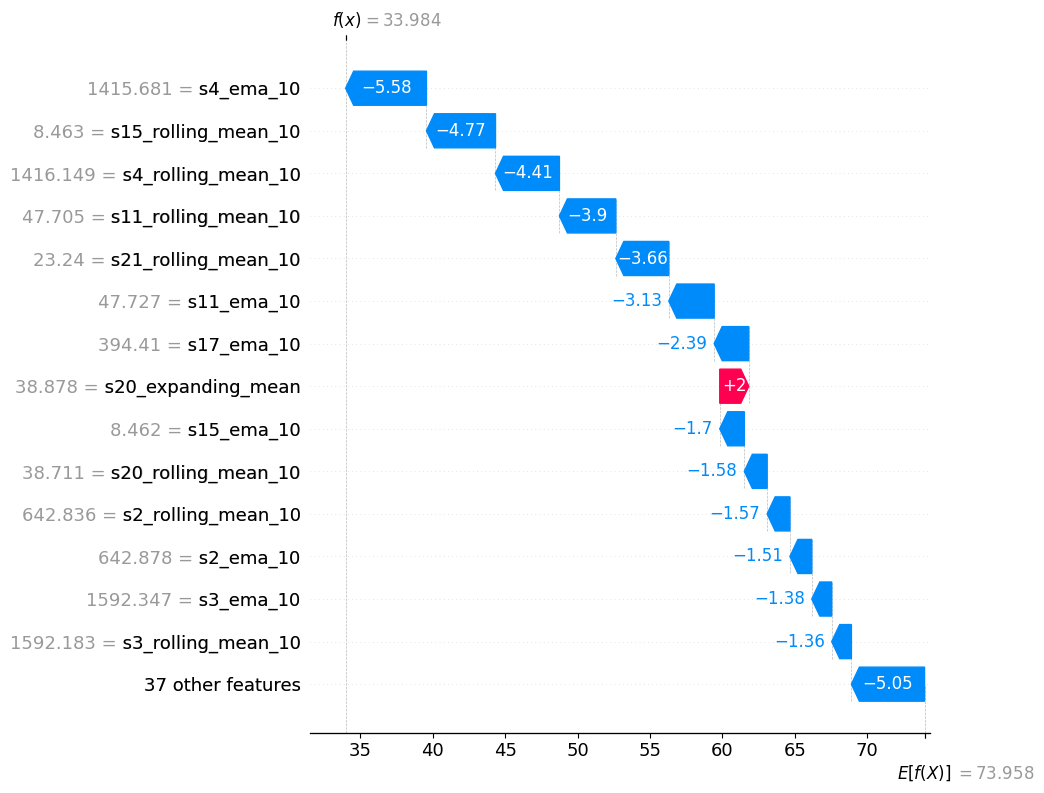

In [76]:
shap.plots.waterfall(
    shap_values[engine_index],
    max_display=15,
)

### Median-Error Prediction

This example represents a typical prediction whose absolute error is
closest to the median error across the official FD001 test engines.

It provides a more representative local explanation than selecting an
engine randomly.

In [77]:
median_engine_index = median_prediction

display(
    prediction_summary.iloc[
        median_engine_index
    ]
)

engine_id                     85.000000
final_cycle                   34.000000
actual_RUL                   118.000000
predicted_RUL_raw            124.091622
predicted_RUL_constrained    124.091622
absolute_error                 6.091622
Name: 84, dtype: float64

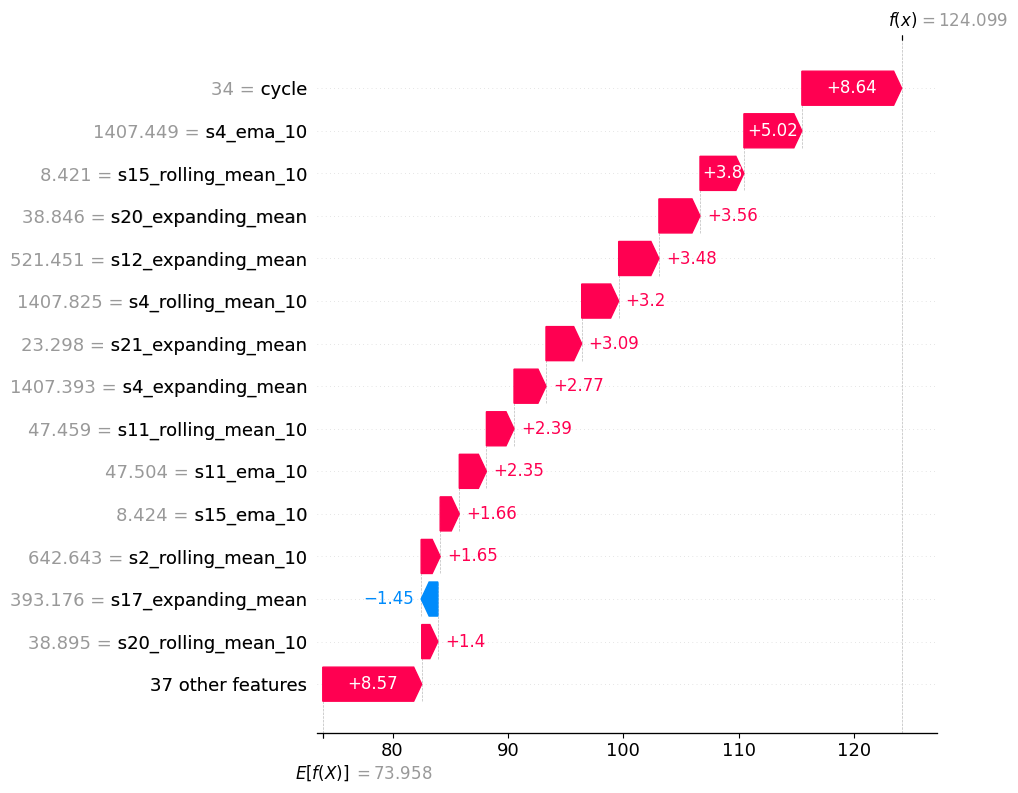

In [78]:
shap.plots.waterfall(
    shap_values[
        median_engine_index
    ],
    max_display=15,
)

### Highest-Error Prediction

This example examines the official test engine with the largest absolute
prediction error.

The explanation helps identify which feature contributions drove the
model toward an inaccurate Remaining Useful Life estimate.

A local SHAP explanation describes the model's reasoning for this sample,
but it does not by itself establish why the prediction error occurred.

In [79]:
worst_engine_index = worst_prediction

display(
    prediction_summary.iloc[
        worst_engine_index
    ]
)

engine_id                     45.000000
final_cycle                  152.000000
actual_RUL                   114.000000
predicted_RUL_raw             65.234401
predicted_RUL_constrained     65.234401
absolute_error                48.765599
Name: 44, dtype: float64

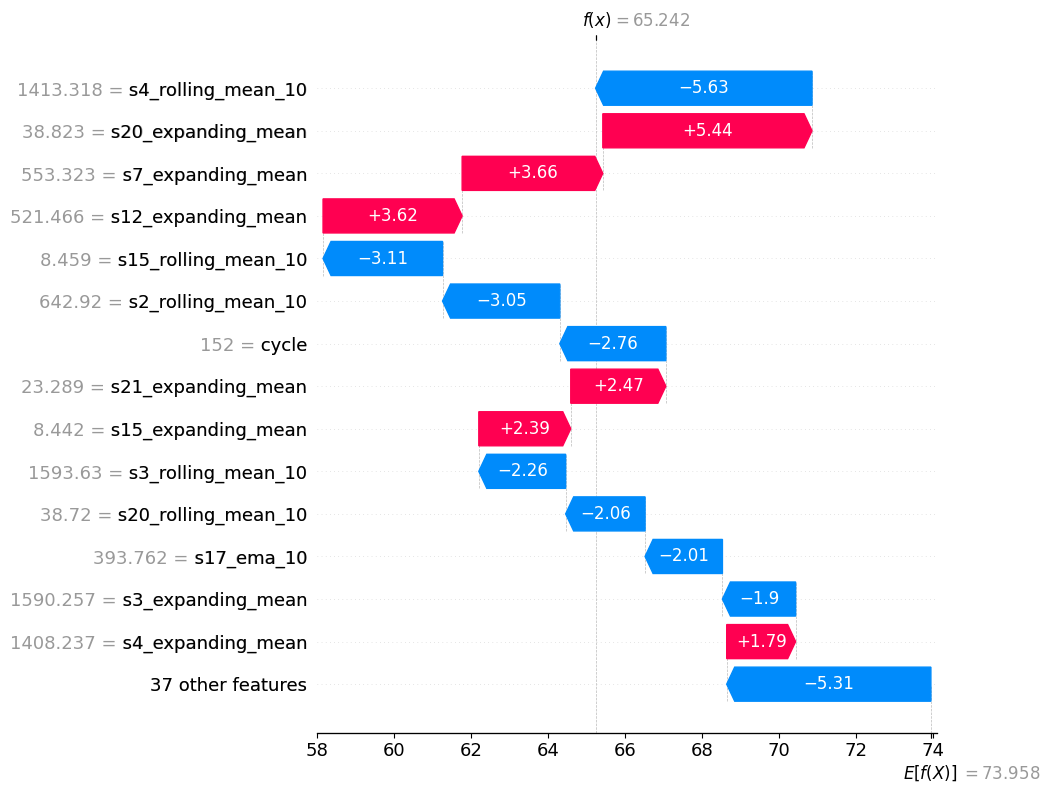

In [80]:
shap.plots.waterfall(
    shap_values[
        worst_engine_index
    ],
    max_display=15,
)

In [81]:
selected_local_explanations = (
    prediction_summary
    .iloc[
        [
            best_prediction,
            median_prediction,
            worst_prediction,
        ]
    ]
    .copy()
)

selected_local_explanations.index = [
    "best",
    "median",
    "worst",
]

display(
    selected_local_explanations[
        [
            "engine_id",
            "final_cycle",
            "actual_RUL",
            "predicted_RUL_constrained",
            "absolute_error",
        ]
    ]
)

,engine_id,final_cycle,actual_RUL,predicted_RUL_constrained,absolute_error
best,77,162,34.0,33.977047,0.022953
median,85,34,118.0,124.091622,6.091622
worst,45,152,114.0,65.234401,48.765599


## 7. SHAP Dependence Analysis

Global importance identifies which features are influential across the
entire official test dataset.

SHAP dependence plots provide additional insight by illustrating how the
value of an individual feature influences its SHAP contribution.

Unlike feature importance rankings, dependence plots reveal:

- nonlinear relationships,
- monotonic trends,
- interaction effects,
- regions where feature influence changes.

The following plots focus on the most influential features identified by
both permutation importance and SHAP analysis.

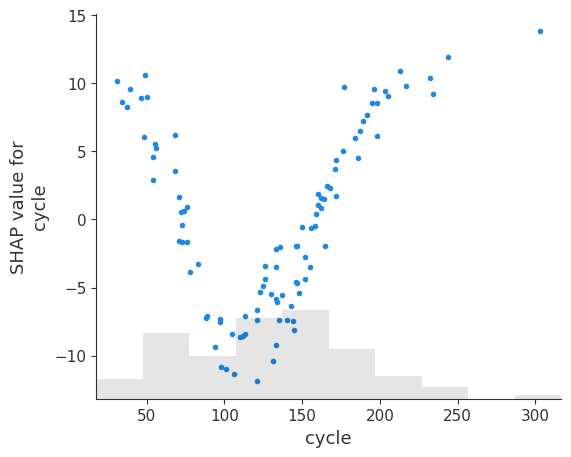

In [82]:
shap.plots.scatter(
    shap_values[:, "cycle"],
)

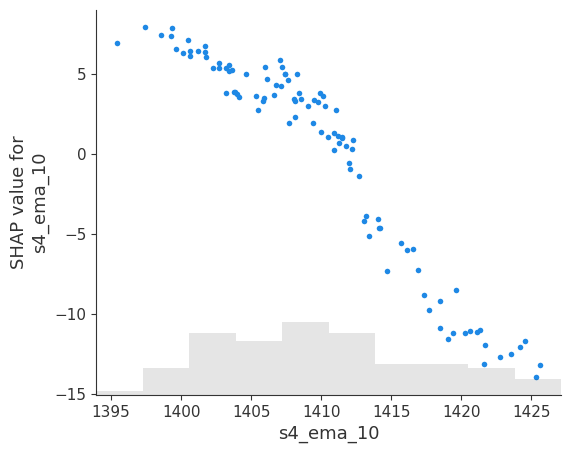

In [83]:
shap.plots.scatter(
    shap_values[:, "s4_ema_10"],
)

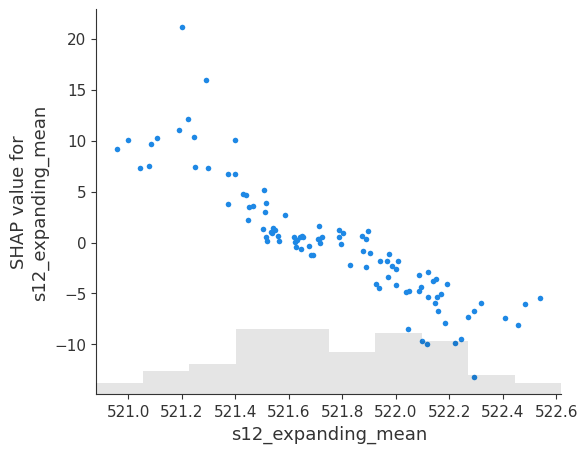

In [84]:
shap.plots.scatter(
    shap_values[:, "s12_expanding_mean"],
)

## 8. Discussion

Several important observations emerge from the interpretability analysis.

### Agreement Between Interpretation Methods

Permutation importance and SHAP produced highly consistent feature
rankings.

The same historical sensor features repeatedly appeared among the most
influential variables, increasing confidence that the observed feature
importance is not an artifact of a single interpretation technique.

### Importance of Historical Features

The strongest predictors are dominated by rolling statistics,
exponential moving averages, and expanding means rather than raw sensor
measurements.

This indicates that the finalized model relies primarily on degradation
trends accumulated over time instead of isolated instantaneous sensor
values.

### Role of Operating Cycle

The operating cycle remains one of the most influential predictors.

This is expected because engine degradation generally progresses with
time.

However, the presence of numerous engineered sensor-history features
demonstrates that the model does not rely exclusively on elapsed cycles.

### Local Explanations

Individual SHAP explanations reveal that different engines are driven by
different combinations of sensor-history features.

Even when two engines receive similar Remaining Useful Life predictions,
the contributing features may differ substantially.

### Numerical Stability

Tree SHAP produced small numerical additivity discrepancies for the
Histogram Gradient Boosting model.

Independent verification showed that these differences are negligible
relative to the prediction scale and do not materially affect the
interpretation results.

# Conclusion

This notebook investigated the behavior of the finalized Histogram
Gradient Boosting model using multiple complementary interpretability
techniques.

The analysis confirmed that:

- permutation importance and SHAP identify consistent feature rankings,
- historical sensor statistics dominate the prediction process,
- engineered temporal features contribute substantially more than raw
  measurements,
- individual predictions can be explained through feature-level SHAP
  attributions,
- numerical SHAP approximation errors remain small relative to the model
  prediction scale.

Together with the official evaluation presented in Notebook 07, these
results demonstrate that the finalized predictive maintenance pipeline is
not only accurate but also interpretable and reproducible.

In [85]:
print("=" * 60)
print("Notebook 08 completed successfully.")
print("=" * 60)

print("Final model:", model_bundle["model_name"])
print("Official MAE:", f"{official_mae:.3f}")
print("Number of interpreted engines:", len(X_official_test))
print("Number of analyzed features:", len(feature_columns))

Notebook 08 completed successfully.
Final model: HistGradientBoostingRegressor
Official MAE: 10.116
Number of interpreted engines: 100
Number of analyzed features: 51
